<a href="https://colab.research.google.com/github/Non8q/IT326-Adult-Census-Income/blob/main/Phase3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, ConfusionMatrixDisplay)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("Preprocessed_dataset.csv")
print("Dataset shape:", df.shape)
print("\nClass distribution:")
print(df['income'].value_counts())
df.head()

Dataset shape: (30162, 15)

Class distribution:
income
0    22654
1     7508
Name: count, dtype: int64


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,3.316630,2,-0.538790,11,-0.439738,6,3,1,4,0,-0.147445,10.555814,-1.914161,38,0
1,1.184831,2,-0.467906,5,-2.400559,0,6,4,4,0,-0.147445,9.427915,-0.077734,38,0
2,0.195067,2,0.708645,15,-0.047574,5,9,3,4,0,-0.147445,9.427915,-0.077734,38,0
3,-0.337883,2,0.256222,11,-0.439738,0,7,4,4,0,-0.147445,9.106365,0.339636,38,0
4,-0.033340,2,-0.370964,0,-1.616231,5,0,4,4,1,-0.147445,9.106365,-0.077734,38,0


## Part 1: Classification using Decision Tree

### Define Features (X) and Target (y)

In [24]:
X = df.drop('income', axis=1)
y = df['income']
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (30162, 14)
Target shape: (30162,)


### Build and Evaluate Models — All Partitions and Criteria

In [25]:
partitions = [
    (0.10, "90% Train / 10% Test"),
    (0.20, "80% Train / 20% Test"),
    (0.30, "70% Train / 30% Test"),
]
criteria = ['entropy', 'gini']

results = {}

for criterion in criteria:
    for test_size, label in partitions:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=42)

        clf = DecisionTreeClassifier(criterion=criterion, max_depth=5, random_state=42)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        key = f"{criterion}_{label}"
        results[key] = {
            "criterion": criterion,
            "partition": label,
            "accuracy": round(acc * 100, 2),
            "model": clf,
            "y_test": y_test,
            "y_pred": y_pred
        }
        print(f"[{criterion.upper():7s}] {label} → Accuracy: {acc*100:.2f}%")

[ENTROPY] 90% Train / 10% Test → Accuracy: 84.32%
[ENTROPY] 80% Train / 20% Test → Accuracy: 84.04%
[ENTROPY] 70% Train / 30% Test → Accuracy: 84.06%
[GINI   ] 90% Train / 10% Test → Accuracy: 84.19%
[GINI   ] 80% Train / 20% Test → Accuracy: 84.40%
[GINI   ] 70% Train / 30% Test → Accuracy: 84.51%


### Accuracy Comparison Table

In [26]:
print("=" * 65)
print(f"{'Criterion':<12} {'90/10':>12} {'80/20':>12} {'70/30':>12}")
print("=" * 65)
for criterion in criteria:
    row = f"{criterion.capitalize():<12}"
    for _, label in partitions:
        acc = results[f"{criterion}_{label}"]["accuracy"]
        row += f" {acc:>11.2f}%"
    print(row)
print("=" * 65)

Criterion           90/10        80/20        70/30
Entropy            84.32%       84.04%       84.06%
Gini               84.19%       84.40%       84.51%


### Confusion Matrices — Entropy (Information Gain)

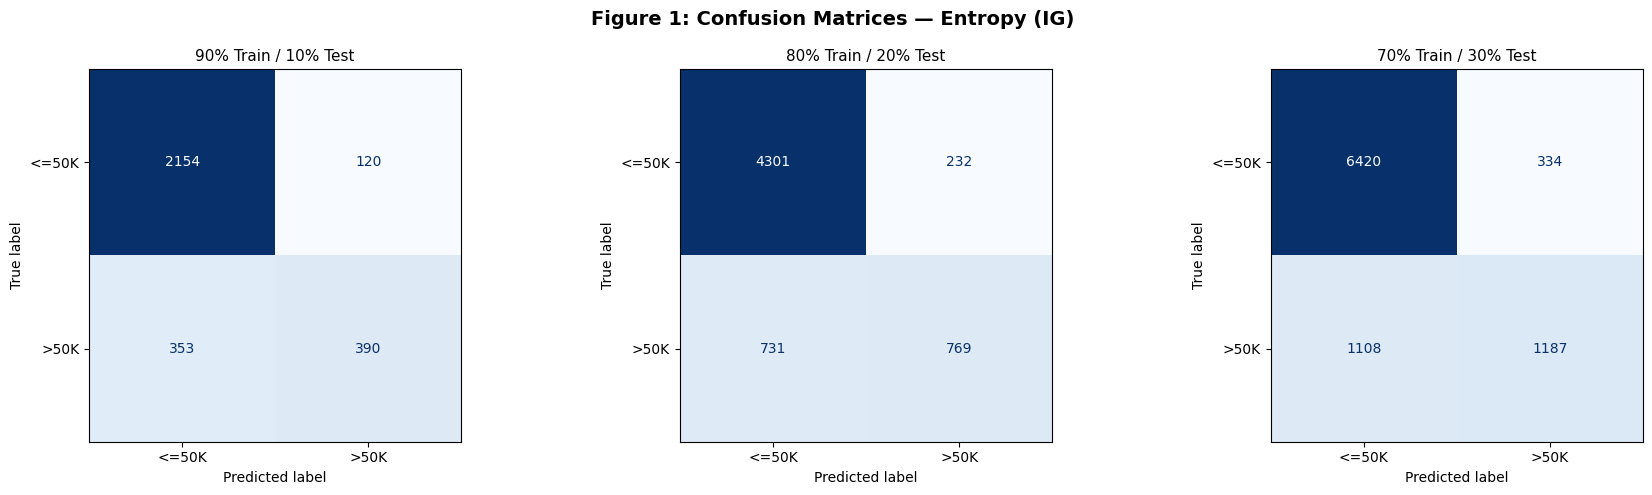

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Figure 1: Confusion Matrices — Entropy (IG)', fontsize=14, fontweight='bold')

for ax, (_, label) in zip(axes, partitions):
    r = results[f"entropy_{label}"]
    cm = confusion_matrix(r['y_test'], r['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['<=50K', '>50K'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(label, fontsize=11)

plt.tight_layout()
plt.show()

### Confusion Matrices — Gini Index

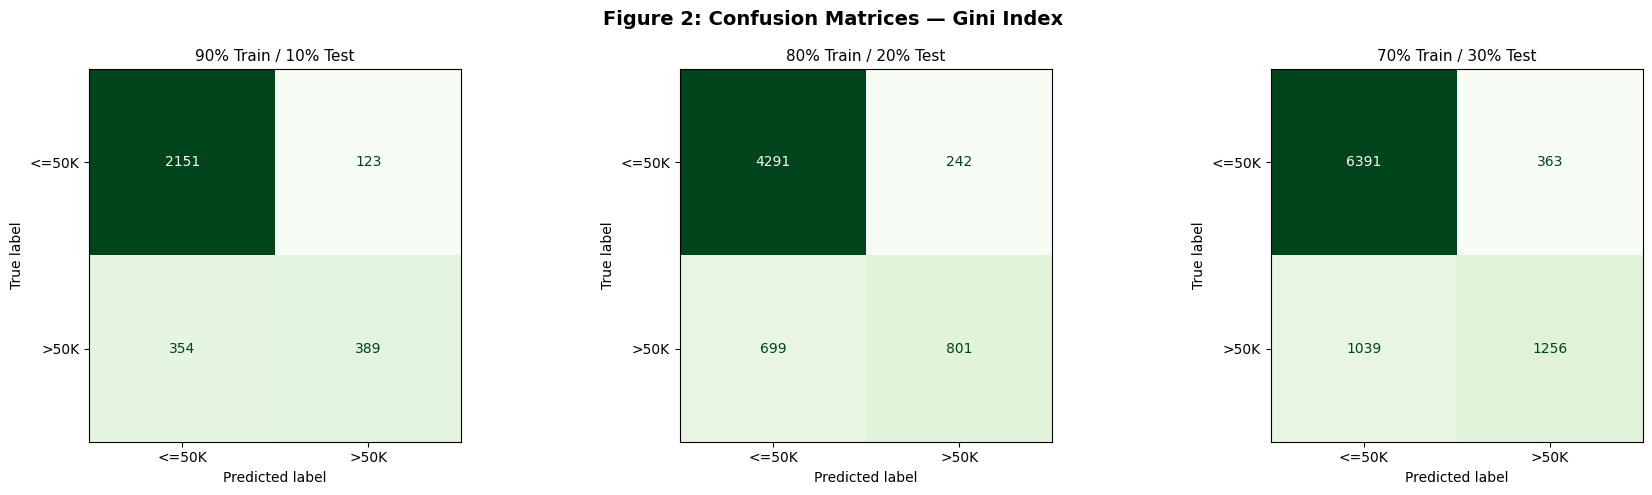

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Figure 2: Confusion Matrices — Gini Index', fontsize=14, fontweight='bold')

for ax, (_, label) in zip(axes, partitions):
    r = results[f"gini_{label}"]
    cm = confusion_matrix(r['y_test'], r['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['<=50K', '>50K'])
    disp.plot(ax=ax, cmap='Greens', colorbar=False)
    ax.set_title(label, fontsize=11)

plt.tight_layout()
plt.show()

### Classification Report — Best Model

In [29]:
# Best overall model: Gini 70/30
best = results["gini_70% Train / 30% Test"]
print("Best Model: Gini Index | 70% Train / 30% Test")
print(f"Accuracy: {best['accuracy']}%\n")
print(classification_report(best['y_test'], best['y_pred'],
                             target_names=['<=50K', '>50K']))

Best Model: Gini Index | 70% Train / 30% Test
Accuracy: 84.51%

              precision    recall  f1-score   support

       <=50K       0.86      0.95      0.90      6754
        >50K       0.78      0.55      0.64      2295

    accuracy                           0.85      9049
   macro avg       0.82      0.75      0.77      9049
weighted avg       0.84      0.85      0.84      9049



### Visualize Decision Tree — Best Model (Gini 80/20)

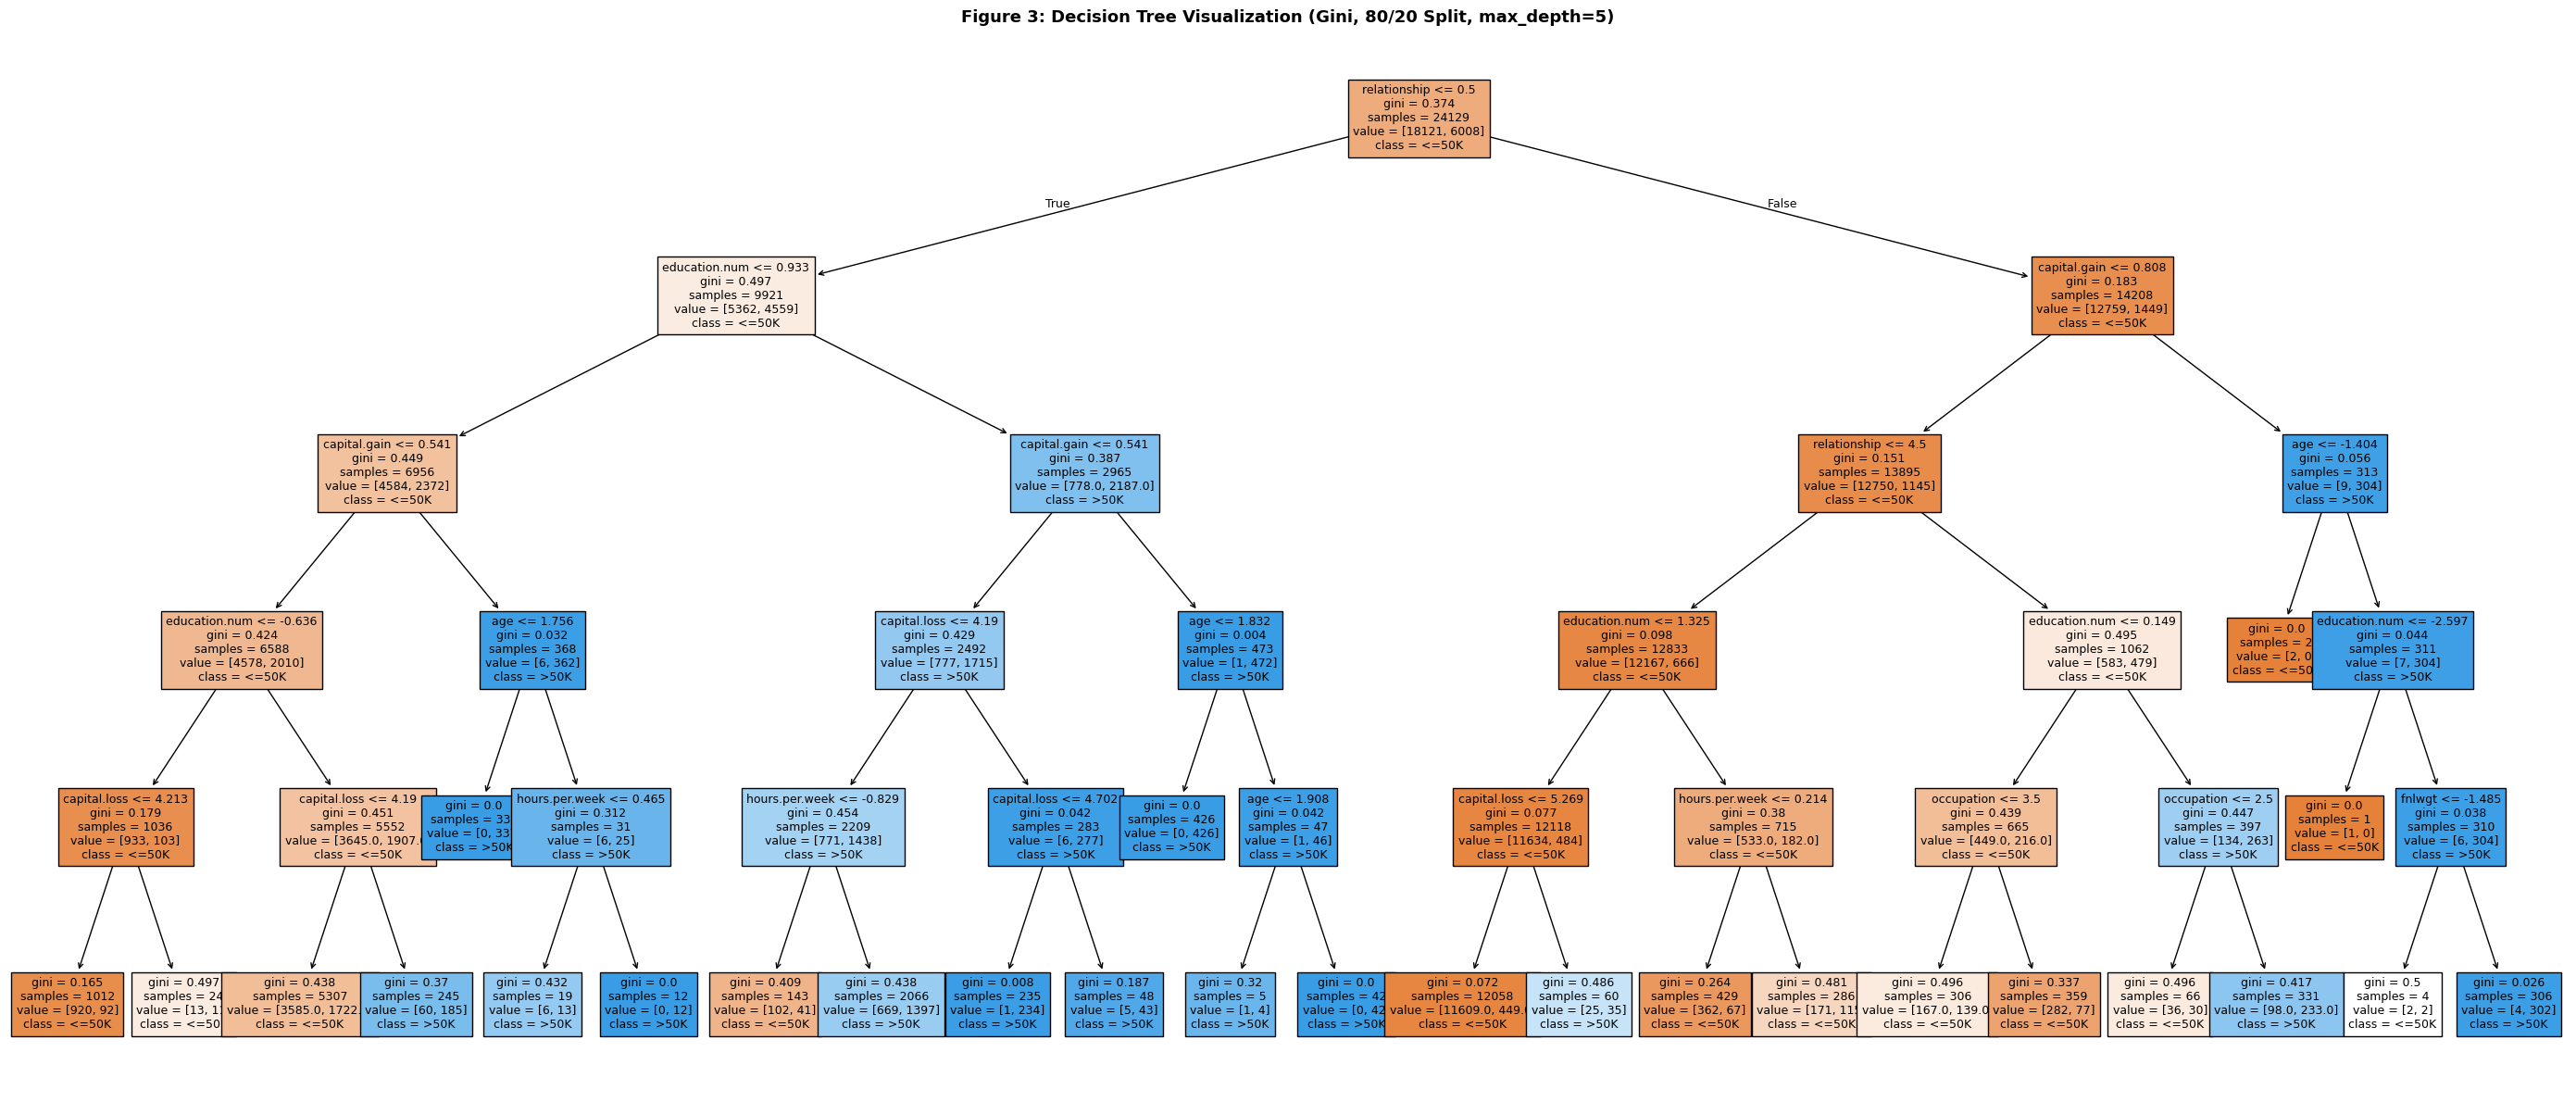

In [30]:
X_train_viz, X_test_viz, y_train_viz, _ = train_test_split(
    X, y, test_size=0.20, random_state=42)
clf_viz = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
clf_viz.fit(X_train_viz, y_train_viz)

plt.figure(figsize=(28, 12))
plot_tree(clf_viz, feature_names=X.columns,
          class_names=['<=50K', '>50K'], filled=True, fontsize=9)
plt.title("Figure 3: Decision Tree Visualization (Gini, 80/20 Split, max_depth=5)",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Part 2: Clustering using K-Means

### Elbow Method — Find Optimal K

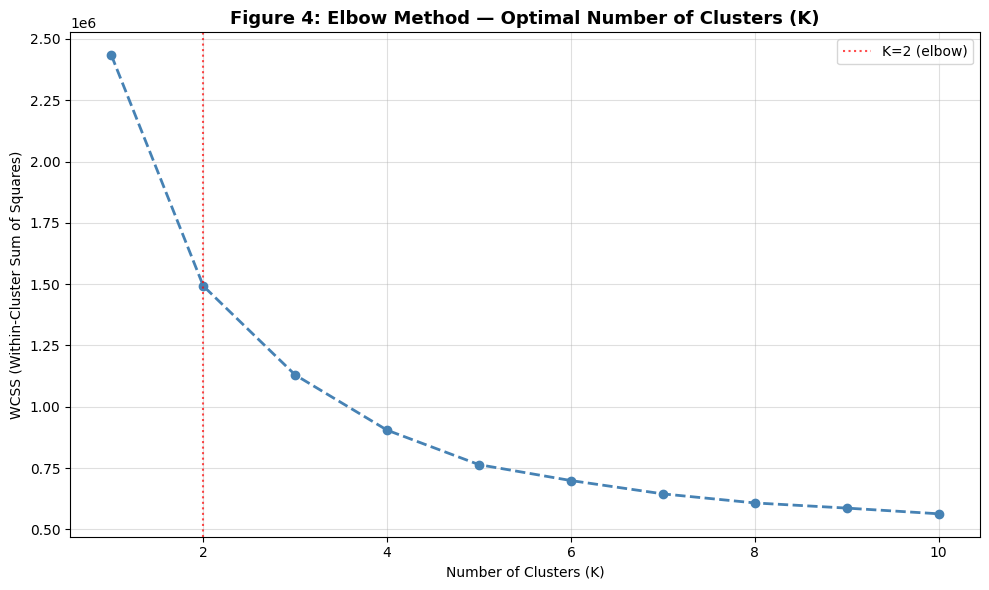

In [31]:
wcss = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    km.fit(X)
    wcss.append(km.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', color='steelblue', linestyle='--', linewidth=2)
plt.axvline(x=2, color='red', linestyle=':', alpha=0.7, label='K=2 (elbow)')
plt.title('Figure 4: Elbow Method — Optimal Number of Clusters (K)', fontsize=13, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

### Apply K-Means for K = 2, 3, 5

In [32]:
k_values = [2, 3, 5]
clustering_results = {}

for k in k_values:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = km.fit_predict(X)
    sil = silhouette_score(X, labels, sample_size=5000, random_state=42)
    clustering_results[k] = {
        "model": km,
        "labels": labels,
        "wcss": round(km.inertia_, 2),
        "silhouette": round(sil, 4)
    }
    print(f"K={k} → WCSS: {km.inertia_:,.0f} | Silhouette: {sil:.4f}")

K=2 → WCSS: 1,492,600 | Silhouette: 0.6302
K=3 → WCSS: 1,129,842 | Silhouette: 0.2820
K=5 → WCSS: 763,974 | Silhouette: 0.3292


### Clustering Evaluation Table

In [33]:
print("=" * 52)
print(f"{'Metric':<38} {'K=2':>4}  {'K=3':>4}  {'K=5':>4}")
print("=" * 52)
print(f"{'Average Silhouette Width':<38}", end="")
for k in k_values:
    print(f" {clustering_results[k]['silhouette']:>5}", end="")
print()
print(f"{'Total WCSS (Within-Cluster Sum of Squares)':<38}", end="")
for k in k_values:
    print(f" {clustering_results[k]['wcss']/1e6:>4.2f}M", end="")
print()
print("=" * 52)

Metric                                  K=2   K=3   K=5
Average Silhouette Width               0.6302 0.282 0.3292
Total WCSS (Within-Cluster Sum of Squares) 1.49M 1.13M 0.76M


### Cluster Visualization — K = 2, 3, 5

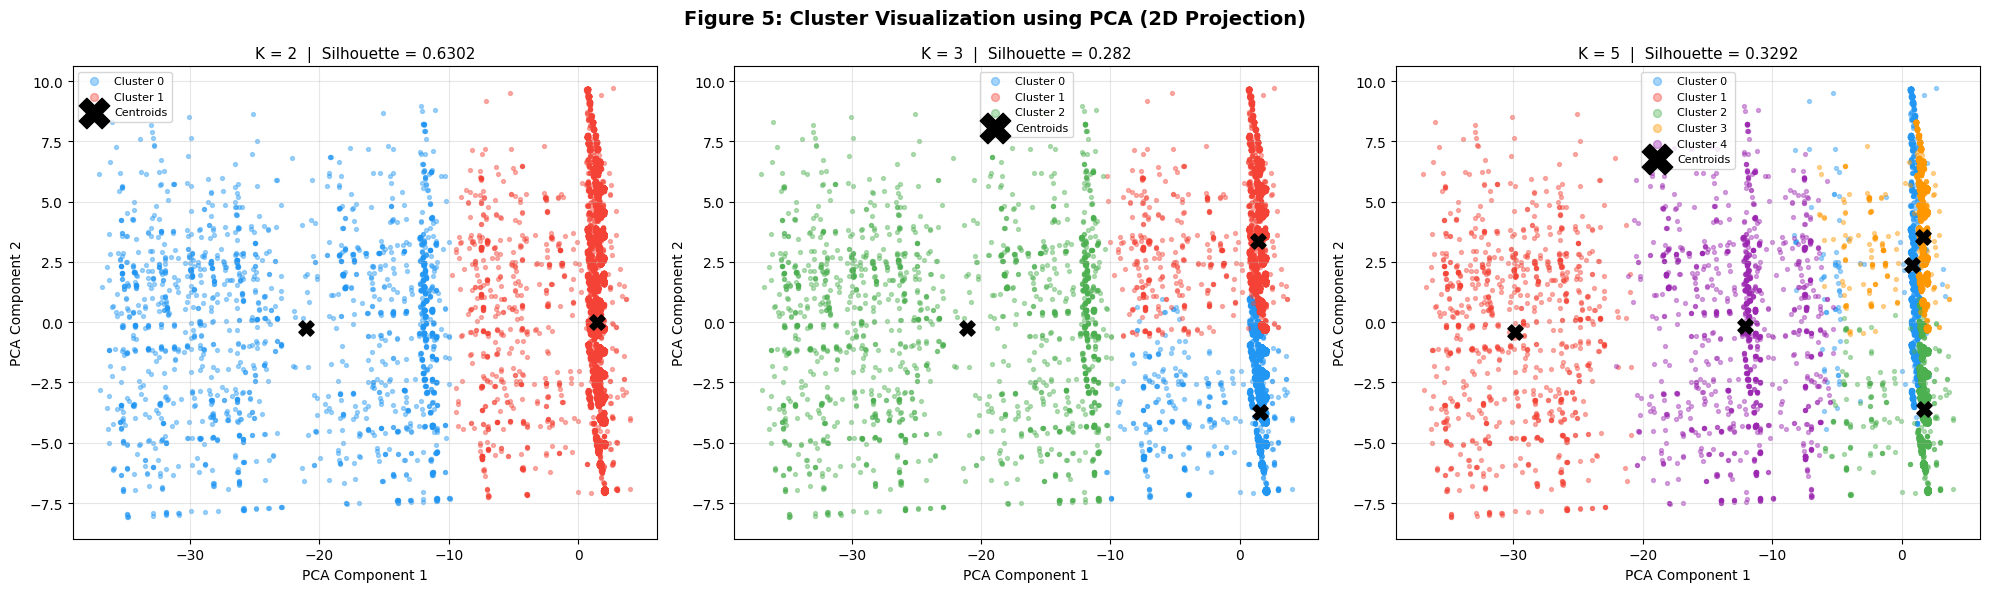

In [34]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Figure 5: Cluster Visualization using PCA (2D Projection)',
             fontsize=14, fontweight='bold')

colors_list = [
    ['#2196F3', '#F44336'],
    ['#2196F3', '#F44336', '#4CAF50'],
    ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0']
]

for ax, k, colors in zip(axes, k_values, colors_list):
    labels = clustering_results[k]['labels']
    for cluster_id in range(k):
        mask = labels == cluster_id
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=colors[cluster_id], label=f'Cluster {cluster_id}',
                   alpha=0.4, s=8)
    centers_pca = pca.transform(clustering_results[k]['model'].cluster_centers_)
    ax.scatter(centers_pca[:, 0], centers_pca[:, 1],
               c='black', marker='X', s=120, zorder=5, label='Centroids')
    ax.set_title(f'K = {k}  |  Silhouette = {clustering_results[k]["silhouette"]}',
                 fontsize=11)
    ax.set_xlabel('PCA Component 1')
    ax.set_ylabel('PCA Component 2')
    ax.legend(fontsize=8, markerscale=2)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Cluster Characterization — Mean Values per Cluster

In [35]:
df_cluster = df.copy()

for k in k_values:
    df_cluster[f'Cluster_K{k}'] = clustering_results[k]['labels']
    print(f"\n--- K={k}: Records per Cluster ---")
    print(df_cluster[f'Cluster_K{k}'].value_counts().sort_index())

print("\n--- K=3: Mean feature values per cluster ---")
print(df_cluster.groupby('Cluster_K3')[['age','education.num','hours.per.week','income']].mean().round(3))


--- K=2: Records per Cluster ---
Cluster_K2
0     1988
1    28174
Name: count, dtype: int64

--- K=3: Records per Cluster ---
Cluster_K3
0    13331
1    14852
2     1979
Name: count, dtype: int64

--- K=5: Records per Cluster ---
Cluster_K5
0     2941
1      922
2    13202
3    11752
4     1345
Name: count, dtype: int64

--- K=3: Mean feature values per cluster ---
              age  education.num  hours.per.week  income
Cluster_K3                                              
0           0.048         -0.016           0.076   0.256
1          -0.033          0.087          -0.065   0.250
2          -0.074         -0.548          -0.021   0.188


### Cluster Visualization — Key Features (K=3)

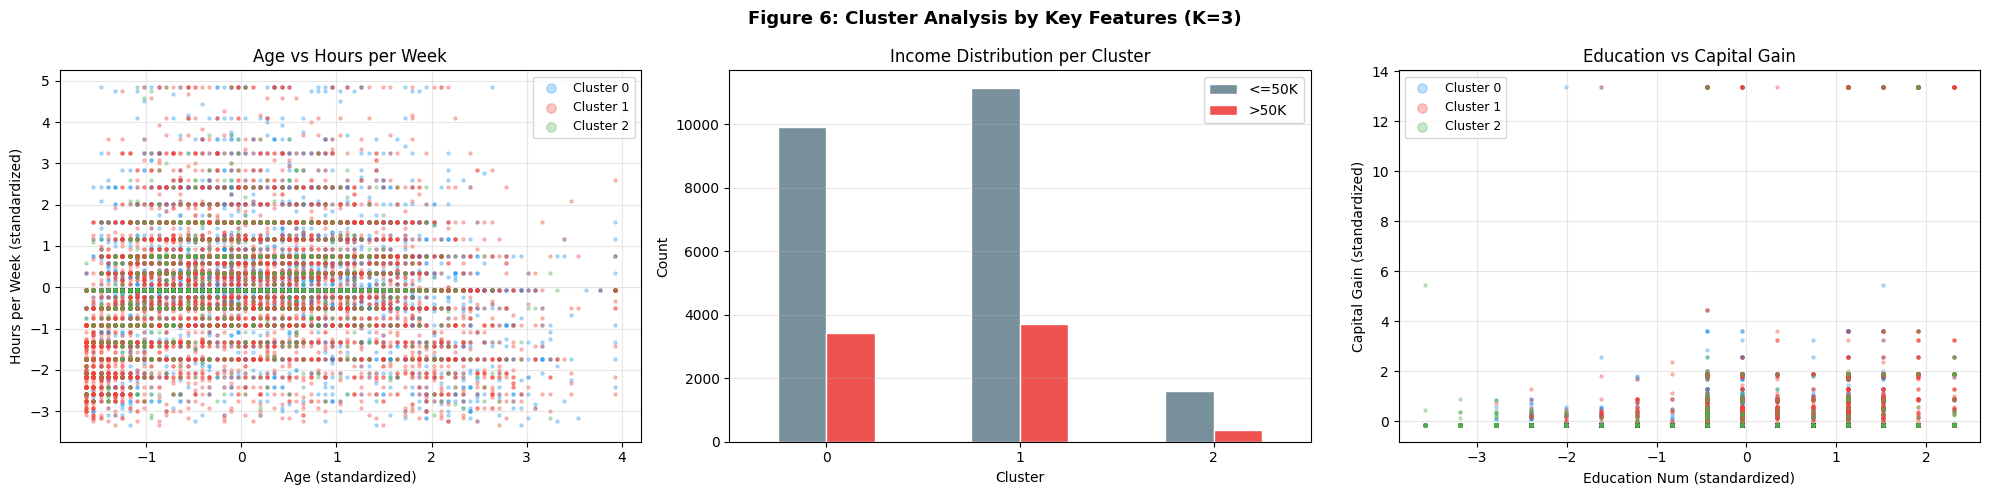

In [36]:
df_plot = df.copy()
df_plot['Cluster'] = clustering_results[3]['labels']
df_plot['income_label'] = df_plot['income'].map({0: '<=50K', 1: '>50K'})

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Figure 6: Cluster Analysis by Key Features (K=3)', fontsize=13, fontweight='bold')

palette = {0: '#2196F3', 1: '#F44336', 2: '#4CAF50'}

# Plot 1: age vs hours.per.week
for c in [0,1,2]:
    mask = df_plot['Cluster'] == c
    axes[0].scatter(df_plot[mask]['age'], df_plot[mask]['hours.per.week'],
                    c=palette[c], alpha=0.3, s=5, label=f'Cluster {c}')
axes[0].set_xlabel('Age (standardized)')
axes[0].set_ylabel('Hours per Week (standardized)')
axes[0].set_title('Age vs Hours per Week')
axes[0].legend(markerscale=3, fontsize=9)
axes[0].grid(True, alpha=0.3)

# Plot 2: income distribution per cluster
cluster_income = df_plot.groupby(['Cluster','income']).size().unstack(fill_value=0)
cluster_income.columns = ['<=50K', '>50K']
cluster_income.plot(kind='bar', ax=axes[1], color=['#78909C','#EF5350'],
                    edgecolor='white', rot=0)
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Count')
axes[1].set_title('Income Distribution per Cluster')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

# Plot 3: education.num vs capital.gain
for c in [0,1,2]:
    mask = df_plot['Cluster'] == c
    axes[2].scatter(df_plot[mask]['education.num'], df_plot[mask]['capital.gain'],
                    c=palette[c], alpha=0.3, s=5, label=f'Cluster {c}')
axes[2].set_xlabel('Education Num (standardized)')
axes[2].set_ylabel('Capital Gain (standardized)')
axes[2].set_title('Education vs Capital Gain')
axes[2].legend(markerscale=3, fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 7. Findings and Discussion

## Classification Findings

Both Decision Tree classifiers (Entropy and Gini) achieved consistent accuracy across all three partitions, ranging from **84.04% to 84.51%**, which demonstrates the model's stability and robustness.

**Key observations:**
- The **Gini index** slightly outperformed Entropy in the 70/30 and 80/20 partitions (84.51% vs 84.06%), suggesting it produces marginally better splits for this dataset.
- Accuracy remains stable across all three partition sizes, indicating the model generalizes well and is not sensitive to the amount of training data within this range.
- The 70/30 split with Gini achieved the **best overall accuracy (84.51%)**, making it the recommended configuration.
- The confusion matrices reveal a **class imbalance effect**: the model predicts ≤50K more accurately than >50K, which aligns with the dataset's 75%/25% class distribution.
- The decision tree visualization (Figure 3) reveals that `relationship`, `capital.gain`, and `education.num` are the most discriminative features, confirming their socio-economic importance.

## Clustering Findings

K-Means was applied with K = 2, 3, and 5:

| K | Silhouette | WCSS |
|---|-----------|------|
| 2 | 0.6302 (best) | 1,492,600 |
| 3 | 0.2820 | 1,129,842 |
| 5 | 0.3292 | 763,974 |

**Key observations:**
- **K=2** achieves the highest silhouette score (0.63), indicating the most compact and well-separated clusters. This aligns with the natural binary nature of the dataset (income ≤50K vs >50K).
- **K=3** produces the weakest silhouette score, suggesting some cluster overlap.
- **K=5** reduces WCSS significantly but only moderately improves silhouette over K=3.
- The **optimal K = 2** is confirmed by both the Elbow method (sharp bend at K=2) and the highest silhouette score.
- Cluster analysis (Figure 6) shows that clusters differ notably in income distribution, education level, and capital gain — confirming that these socio-economic features drive natural groupings in the population.

